# Gradient Boosted Survival Model
**In this notebook, we'll train and test a gradient boosting survival model from scikit-learn to predict 6 month survival from time of first-line treatment for metastatic RCC.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer

from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import cumulative_dynamic_auc

import matplotlib.pyplot as plt

from utils.cv_predictions import cross_validated_survival_predictions

## Import

In [2]:
dtype_map = pd.read_csv('../outputs/1L_features_training_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
train_df = pd.read_csv('../outputs/1L_features_training.csv', dtype = dtype_map)
train_df.shape

(6628, 155)

In [3]:
dtype_map = pd.read_csv('../outputs/1L_features_testing_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
test_df = pd.read_csv('../outputs/1L_features_testing.csv', dtype = dtype_map)
test_df.shape

(1663, 155)

In [4]:
censored_before_6m = (len(train_df.query('event == 0 and duration < 180', engine = 'python'))/len(train_df))*100
censored_before_12m = (len(train_df.query('event == 0 and duration < 365', engine = 'python'))/len(train_df))*100

print(f'Percentage censored before 6 months: {round(censored_before_6m, 1)}%')
print(f'Percentage censored before 12 months: {round(censored_before_12m, 1)}%')

Percentage censored before 6 months: 9.0%
Percentage censored before 12 months: 14.8%


## Preprocess

### Selecting features

#### Categorical variables

In [5]:
list(train_df.select_dtypes(include = ['category']).columns)

['GroupStage',
 'StageFourDetail',
 'NephrectomyType_mod',
 'met_diagnosis_year',
 'Histology_grouped',
 'Ethnicity_mod',
 'Race_mod',
 'region',
 'PDL1_status']

In [6]:
var_dict = {}
for var in train_df.select_dtypes(include=['category']).columns:
    value_props = train_df[var].value_counts(normalize=True)
    # Combine 'unknown' and 'Unknown' if both exist
    unknown_pct = value_props.get('unknown', 0) + value_props.get('Unknown', 0) + value_props.get('other/unknown', 0)
    var_dict[var] = round(unknown_pct*100, 3)

var_dict

{'GroupStage': np.float64(3.395),
 'StageFourDetail': np.float64(47.571),
 'NephrectomyType_mod': np.float64(37.96),
 'met_diagnosis_year': 0,
 'Histology_grouped': 0,
 'Ethnicity_mod': 0,
 'Race_mod': 0,
 'region': np.float64(16.732),
 'PDL1_status': np.float64(97.088)}

In [7]:
categorical_var = [
    'GroupStage',
    'StageFourDetail',
    'NephrectomyType_mod',
    'Histology_grouped'
]

#### Binary variables 

In [8]:
list(train_df.select_dtypes(include = ['int']).columns)

['SmokingStatus',
 'Nephrectomy_mod',
 'days_met_to_treatment',
 'age',
 'sex_male',
 'ecog_newly_gte2',
 'ecog_index_na',
 'hypotension',
 'tachycardia',
 'fevers',
 'hypoxemia',
 'anticoagulant',
 'opioid',
 'steroid',
 'antibiotic',
 'diabetic_med',
 'antidepressant',
 'bone_therapy_agent',
 'immunosuppressant',
 'chf',
 'cardiac_arrhythmias',
 'valvular_disease',
 'pulm_circulation',
 'pvd',
 'htn_uncomplicated',
 'htn_complicated',
 'paralysis',
 'other_neuro',
 'chronic_pulm_disease',
 'diabetes_uncomplicated',
 'diabetes_complicated',
 'hypothyroid',
 'renal_failure',
 'liver_disease',
 'pud',
 'aids_hiv',
 'lymphoma',
 'rheumatic',
 'coagulopathy',
 'obesity',
 'weight_loss',
 'fluid',
 'blood_loss_anemia',
 'deficiency_anemia',
 'alcohol_abuse',
 'drug_abuse',
 'psychoses',
 'depression',
 'van_walraven_score',
 'lymph_met',
 'thoracic_met',
 'liver_met',
 'bone_met',
 'brain_met',
 'other_met',
 'gi_met_combined',
 'event']

In [9]:
# Did not include days_met_to_treatment, age, van_walraven, or event
bin_list = [
     'SmokingStatus',
     'Nephrectomy_mod',
     'sex_male',
     'ecog_newly_gte2',
     'ecog_index_na',
     'hypotension',
     'tachycardia',
     'fevers',
     'hypoxemia',
     'anticoagulant',
     'opioid',
     'steroid',
     'antibiotic',
     'diabetic_med',
     'antidepressant',
     'bone_therapy_agent',
     'immunosuppressant',
     'chf',
     'cardiac_arrhythmias',
     'valvular_disease',
     'pulm_circulation',
     'pvd',
     'htn_uncomplicated',
     'htn_complicated',
     'paralysis',
     'other_neuro',
     'chronic_pulm_disease',
     'diabetes_uncomplicated',
     'diabetes_complicated',
     'hypothyroid',
     'renal_failure',
     'liver_disease',
     'pud',
     'aids_hiv',
     'lymphoma',
     'rheumatic',
     'coagulopathy',
     'obesity',
     'weight_loss',
     'fluid',
     'blood_loss_anemia',
     'deficiency_anemia',
     'alcohol_abuse',
     'drug_abuse',
     'psychoses',
     'depression',
     'lymph_met',
     'thoracic_met',
     'liver_met',
     'bone_met',
     'brain_met',
     'other_met',
     'gi_met_combined'
]

In [10]:
# Identify binary variables with >=3% prevalence 
bin_var_list = []
for bin_var in bin_list:
    if (train_df[bin_var].value_counts(normalize = True)[1] >= 0.03):
        bin_var_list.append(bin_var)

In [11]:
bin_var_list

['SmokingStatus',
 'Nephrectomy_mod',
 'sex_male',
 'ecog_index_na',
 'tachycardia',
 'opioid',
 'bone_therapy_agent',
 'cardiac_arrhythmias',
 'htn_uncomplicated',
 'chronic_pulm_disease',
 'diabetes_uncomplicated',
 'hypothyroid',
 'renal_failure',
 'obesity',
 'weight_loss',
 'fluid',
 'deficiency_anemia',
 'depression',
 'lymph_met',
 'thoracic_met',
 'liver_met',
 'bone_met',
 'brain_met',
 'other_met',
 'gi_met_combined']

In [12]:
# ecog_index_na added as flag later
binary_var = [
    'SmokingStatus',
    'Nephrectomy_mod',
    'sex_male',
    'tachycardia',
    'opioid',
    'bone_therapy_agent',
    'cardiac_arrhythmias',
    'htn_uncomplicated',
    'chronic_pulm_disease',
    'diabetes_uncomplicated',
    'hypothyroid',
    'renal_failure',
    'obesity',
    'weight_loss',
    'fluid',
    'deficiency_anemia',
    'depression',
    'lymph_met',
    'thoracic_met',
    'liver_met',
    'bone_met',
    'brain_met',
    'other_met',
    'gi_met_combined'
]

#### Numerical variables

In [13]:
list(train_df.select_dtypes(include = ['float64']).columns)

['days_diagnosis_to_met',
 'days_diag_to_treatment',
 'ecog_index',
 'weight_index',
 'bmi_index',
 'percent_change_weight',
 'albumin',
 'alp',
 'alt',
 'ast',
 'bicarbonate',
 'bun',
 'calcium',
 'chloride',
 'creatinine',
 'hemoglobin',
 'neutrophil',
 'platelet',
 'potassium',
 'sodium',
 'total_bilirubin',
 'wbc',
 'albumin_max',
 'alp_max',
 'alt_max',
 'ast_max',
 'bicarbonate_max',
 'bun_max',
 'calcium_max',
 'chloride_max',
 'creatinine_max',
 'hemoglobin_max',
 'neutrophil_max',
 'platelet_max',
 'potassium_max',
 'sodium_max',
 'total_bilirubin_max',
 'wbc_max',
 'albumin_min',
 'alp_min',
 'alt_min',
 'ast_min',
 'bicarbonate_min',
 'bun_min',
 'calcium_min',
 'chloride_min',
 'creatinine_min',
 'hemoglobin_min',
 'neutrophil_min',
 'platelet_min',
 'potassium_min',
 'sodium_min',
 'total_bilirubin_min',
 'wbc_min',
 'albumin_std',
 'alp_std',
 'alt_std',
 'ast_std',
 'bicarbonate_std',
 'bun_std',
 'calcium_std',
 'chloride_std',
 'creatinine_std',
 'hemoglobin_std',
 'ne

In [14]:
# Add days_met_to_treatment, age, and van_walraven_score here even though not float 
numerical_var = [
    'days_diagnosis_to_met',
    'days_diag_to_treatment',
    'ecog_index',
    'weight_index',
    'bmi_index',
    'percent_change_weight',
    'albumin',
    'alp',
    'alt',
    'ast',
    'bicarbonate',
    'bun',
    'calcium',
    'chloride',
    'creatinine',
    'hemoglobin',
    'neutrophil',
    'platelet',
    'potassium',
    'sodium',
    'total_bilirubin',
    'wbc',
    'alp_max',
    'alt_max',
    'ast_max',
    'calcium_max',
    'creatinine_max',
    'hemoglobin_max',
    'neutrophil_max',
    'platelet_max',
    'potassium_max',
    'sodium_max',
    'total_bilirubin_max',
    'wbc_max',
    'albumin_min',
    'bicarbonate_min',
    'calcium_min',
    'hemoglobin_min',
    'neutrophil_min', 
    'platelet_min',
    'potassium_min',
    'sodium_min',
    'wbc_min',
    'days_met_to_treatment',
    'age', 
    'van_walraven_score'
]

In [15]:
all_var = categorical_var + binary_var + numerical_var

In [16]:
missing = train_df[all_var].isnull().sum()
missing[missing > 0].sort_values(ascending = False)

van_walraven_score        3353
neutrophil                2763
neutrophil_min            2690
neutrophil_max            2690
chloride                  2250
albumin                   2001
bicarbonate               1916
total_bilirubin           1897
albumin_min               1894
alt                       1867
ast                       1827
alp                       1825
calcium                   1809
bicarbonate_min           1807
potassium                 1796
sodium                    1795
creatinine                1787
total_bilirubin_max       1787
bun                       1778
alt_max                   1753
alp_max                   1713
ast_max                   1713
percent_change_weight     1707
calcium_max               1699
calcium_min               1699
potassium_max             1686
potassium_min             1686
sodium_min                1685
sodium_max                1685
creatinine_max            1679
platelet                  1262
wbc                       1252
hemoglob

In [17]:
# Create a missing flag
for x in missing[missing > 0].index:
    train_df[f'{x}_na'] = np.where(train_df[x].isna(), 1, 0)
    test_df[f'{x}_na'] = np.where(test_df[x].isna(), 1, 0)

In [18]:
# Add missing flags to binary_var (this includes ecog_index_na)
binary_var = binary_var + [col for col in train_df.columns if col.endswith('_na')]

In [19]:
all_var = categorical_var + binary_var + numerical_var

In [20]:
len(all_var)

117

### Setting up Y

In [21]:
y_dtype = [('event', bool), ('duration', float)]

In [22]:
# Death status and time until event needs to be stored as a structured array to be compatible with scikit-survival
train_y = np.array([tuple(x) for x in train_df[['event', 'duration']].values], 
                   dtype = y_dtype)

test_y = np.array([tuple(x) for x in test_df[['event', 'duration']].values], 
                  dtype = y_dtype)

### Creating pipeline

In [23]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median'))
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown = "ignore", sparse_output = False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_var),
        ("cat", categorical_pipeline, categorical_var),
        ("pass", "passthrough", binary_var),
    ],
    remainder="drop"
)

## Train model

In [24]:
def six_month_auc_scorer_approximate(estimator, X, y):
    """
    Approximate 180d AUC using test set for censoring estimation.
    This is not ideal but may be acceptable if censoring is light (eg., <20%).
    """
    chf_funcs = estimator.predict_cumulative_hazard_function(X)
    risk_scores = np.array([chf(180) for chf in chf_funcs])
    
    # Use same y for both (not ideal, but functional)
    auc, _ = cumulative_dynamic_auc(y, y, risk_scores, 180)
    return auc[0]

auc_scorer = make_scorer(
    six_month_auc_scorer_approximate,
    greater_is_better = True,
    needs_proba = False  
)

param_distributions = {
    'model__n_estimators': [300, 500, 700],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3, 4],
    'model__subsample': [0.75, 0.85],
    'model__max_features': [0.7, 0.9]
}

gb = GradientBoostingSurvivalAnalysis(random_state = 42)

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', gb)
])

search = RandomizedSearchCV(
    estimator = full_pipeline, 
    param_distributions = param_distributions, 
    n_iter = 20, 
    cv = 3,
    scoring = six_month_auc_scorer_approximate,
    refit = False,
    n_jobs = -1,
    random_state = 42,
    verbose = 1
)

search.fit(train_df[all_var], train_y)

print(f"Best params: {search.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'model__subsample': 0.75, 'model__n_estimators': 700, 'model__max_features': 0.9, 'model__max_depth': 2, 'model__learning_rate': 0.05}


In [25]:
results_df = pd.DataFrame(search.cv_results_)
results_df.sort_values('rank_test_score', ascending = True).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__subsample,param_model__n_estimators,param_model__max_features,param_model__max_depth,param_model__learning_rate,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
6,156.780007,1.553500,0.095469,0.013471,0.75,700,0.9,2,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.803435,0.765811,0.790689,0.786645,0.015624,1
0,154.650989,1.414847,0.091763,0.009480,0.75,700,0.7,2,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.802247,0.766562,0.790581,0.786463,0.014856,2
15,158.590072,1.615725,0.084813,0.007147,0.75,700,0.9,3,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.798694,0.769608,0.789987,0.786096,0.012189,3
2,68.946284,0.626593,0.077176,0.009179,0.75,300,0.9,3,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.799283,0.767520,0.790461,0.785755,0.013387,4
9,69.702493,0.727575,0.076522,0.002873,0.75,300,0.9,3,0.10,"{'model__subsample': 0.75, 'model__n_estimator...",0.797568,0.769452,0.789225,0.785415,0.011790,5
12,118.503710,0.843341,0.079851,0.014118,0.85,500,0.9,2,0.05,"{'model__subsample': 0.85, 'model__n_estimator...",0.801191,0.764375,0.790639,0.785402,0.015480,6
14,163.448720,1.423206,0.072161,0.002470,0.85,700,0.7,2,0.05,"{'model__subsample': 0.85, 'model__n_estimator...",0.798180,0.765185,0.791871,0.785079,0.014301,7
8,68.271699,0.674937,0.083410,0.021044,0.75,300,0.7,3,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.796431,0.767686,0.788801,0.784306,0.012158,8
18,114.640200,2.986071,0.073250,0.001373,0.85,500,0.9,4,0.05,"{'model__subsample': 0.85, 'model__n_estimator...",0.797643,0.766019,0.788975,0.784213,0.013343,9
13,118.200102,0.683030,0.077527,0.001658,0.85,500,0.9,2,0.10,"{'model__subsample': 0.85, 'model__n_estimator...",0.799729,0.764158,0.788131,0.784006,0.014812,10


## Test model 

### Build final model 

In [26]:
best_gb_model = GradientBoostingSurvivalAnalysis(
    n_estimators = 700,  
    learning_rate = 0.05,
    max_depth = 2,
    subsample = 0.75,
    max_features = 0.9,
    verbose = 1,
    random_state = 42
)

full_pipeline_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_gb_model)
])

full_pipeline_final.fit(train_df[all_var], train_y)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1       23494.0714           4.8318            6.25m
         2       23155.2450        -271.4756            5.73m
         3       23445.5154         266.1926            5.58m
         4       23552.2891         104.0647            5.49m
         5       23283.0787        -213.3947            5.44m
         6       23278.8448          12.2331            5.40m
         7       23412.0298         128.4072            5.37m
         8       23157.9437        -202.7301            5.35m
         9       23230.7221          73.4103            5.34m
        10       23575.4656         312.3454            5.35m
        20       23165.5938          31.4461            5.25m
        30       23143.4716          41.7987            5.15m
        40       23030.3514          82.7590            5.05m
        50       23138.3815         225.3300            4.96m
        60       23266.1597          84.2724            4.87m
       

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['days_diagnosis_to_met',
                                                   'days_diag_to_treatment',
                                                   'ecog_index', 'weight_index',
                                                   'bmi_index',
                                                   'percent_change_weight',
                                                   'albumin', 'alp', 'alt',
                                                   'ast', 'bicarbonate', 'bun',
                                                   'calcium', 'chloride',
                                                   'creatinine', 'hemoglobin',
                                                   'neutro...
                                                   'thoracic_met', 'liver_met',
                                                   'bone_met', 'brain_met',
                                                   'other_met',
                                                   'gi_met_combined',
                                                   'ecog_index_na',
                                                   'days_diag_to_treatment_na',
                                                   'weight_index_na',
                                                   'bmi_index_na',
                                                   'percent_change_weight_na',
                                                   'albumin_na', ...])])),
                ('model',
                 GradientBoostingSurvivalAnalysis(learning_rate=0.05,
                                                  max_depth=2, max_features=0.9,
                                                  n_estimators=700,
                                                  random_state=42,
                                                  subsample=0.75, verbose=1))])

### Evaluate performance on test and training set 

In [27]:
final_risk_scores_test = full_pipeline_final.predict(test_df[all_var])
final_auc_test = cumulative_dynamic_auc(train_y, test_y, final_risk_scores_test, 180)[0][0]

print(f"Final 180-d AUC on Test Set: {final_auc_test:.3f}")

Final 180-d AUC on Test Set: 0.795


In [28]:
# Bootstrap 1000 180d AUCs for test set 
n_bootstraps = 1000
bootstrapped_scores_test = []

rng = np.random.RandomState(42)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(final_risk_scores_test), len(final_risk_scores_test))
    auc_yr = cumulative_dynamic_auc(
        train_y,
        test_y[indices],
        final_risk_scores_test[indices],
        180
    )[0][0]
    bootstrapped_scores_test.append(auc_yr)

# Convert to array
bootstrapped_scores_test = np.array(bootstrapped_scores_test)

# Calculate 95% CI
conf_lower_test = np.percentile(bootstrapped_scores_test, 2.5)
conf_upper_test = np.percentile(bootstrapped_scores_test, 97.5)

In [29]:
final_risk_scores_train = full_pipeline_final.predict(train_df[all_var])
final_auc_train = cumulative_dynamic_auc(train_y, train_y, final_risk_scores_train, 180)[0][0]

print(f"Final 180-d AUC on Train Set: {final_auc_train:.3f}")

Final 180-d AUC on Train Set: 0.820


In [30]:
# Bootstrap 1000 180d AUCs for train set 
n_bootstraps = 1000
bootstrapped_scores_train = []

rng = np.random.RandomState(42)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(final_risk_scores_train), len(final_risk_scores_train))
    auc_yr = cumulative_dynamic_auc(
        train_y,
        train_y[indices],
        final_risk_scores_train[indices],
        180
    )[0][0]
    bootstrapped_scores_train.append(auc_yr)

# Convert to array
bootstrapped_scores_train = np.array(bootstrapped_scores_train)

# Calculate 95% CI
conf_lower_train = np.percentile(bootstrapped_scores_train, 2.5)
conf_upper_train = np.percentile(bootstrapped_scores_train, 97.5)

In [31]:
gbm_auc_180d_data = {'model': ['gbm'],
                    'auc_180d_test': final_auc_test,
                    'auc_180d_test_lower': conf_lower_test,
                    'auc_180d_test_upper': conf_upper_test,
                    'auc_180d_train': final_auc_train,
                    'auc_180d_train_lower': conf_lower_train,
                    'auc_180d_train_upper': conf_upper_train}
 
gbm_auc_180d_df = pd.DataFrame(gbm_auc_180d_data)

In [32]:
gbm_auc_180d_df

,model,auc_180d_test,auc_180d_test_lower,auc_180d_test_upper,auc_180d_train,auc_180d_train_lower,auc_180d_train_upper
0,gbm,0.795401,0.767795,0.820228,0.820388,0.807625,0.833487


In [33]:
gbm_auc_180d_df.to_csv('../outputs/gbm_auc_180d_df.csv', index = False, header = True)

In [34]:
# Define evaluation times
times = np.arange(30, 1810, 30)

# Calculate AUCs across times
gbm_auc_over5 = cumulative_dynamic_auc(train_y, test_y, final_risk_scores_test, times)[0]

# Build a dictionary mapping 'time_x' -> AUC at that time
times_data = {f"time_{int(t)}": auc for t, auc in zip(times, gbm_auc_over5)}

# Create DataFrame
gbm_auc_over5_df = pd.DataFrame(times_data, index=['gbm'])

In [35]:
gbm_auc_over5_df

,time_30,time_60,time_90,time_120,time_150,time_180,time_210,time_240,time_270,time_300,...,time_1530,time_1560,time_1590,time_1620,time_1650,time_1680,time_1710,time_1740,time_1770,time_1800
gbm,0.799118,0.820585,0.815179,0.807971,0.800601,0.795401,0.786842,0.780068,0.779834,0.774046,...,0.750167,0.749981,0.751606,0.754643,0.755054,0.755467,0.759628,0.762554,0.761725,0.760968


In [36]:
gbm_auc_over5_df.to_csv('../outputs/gbm_auc_over5_df.csv', index = True, header = True)

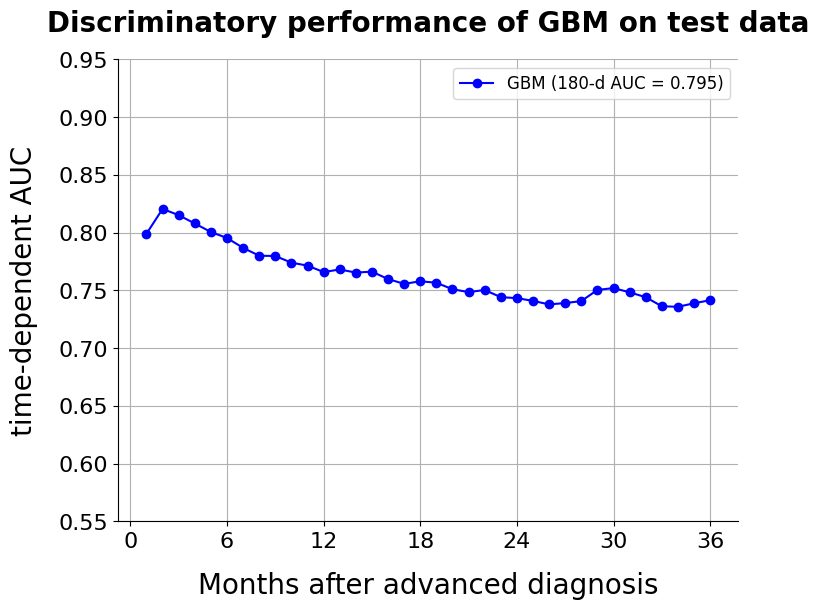

In [37]:
fig, ax0 = plt.subplots(figsize=(8, 6))

# Discriminatory performance plot
times = np.arange(30, 1095, 30)

ax0.plot(times/30, 
         gbm_auc_over5_df.loc['gbm'].values[0:36], 
         'o-', 
         color = 'blue', 
         label = f"GBM (180-d AUC = {final_auc_test:.3f})")

ax0.set_xticks(np.arange(0, 37, 6))
ax0.set_yticks(np.arange(0.55, 1.0, 0.05))
ax0.tick_params(axis = 'both', which = 'major', labelsize = 16) 

ax0.set_title('Discriminatory performance of GBM on test data', weight = 'bold', size = 20, pad = 20)
ax0.set_xlabel('Months after advanced diagnosis', labelpad = 15, size = 20)
ax0.set_ylabel('time-dependent AUC', labelpad = 15, size = 20)
ax0.legend(loc = 'upper right', prop = {'size': 12})
ax0.grid(True)

ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)

plt.show()

Total number of features: 117
Number of non-zero features in final model: 80


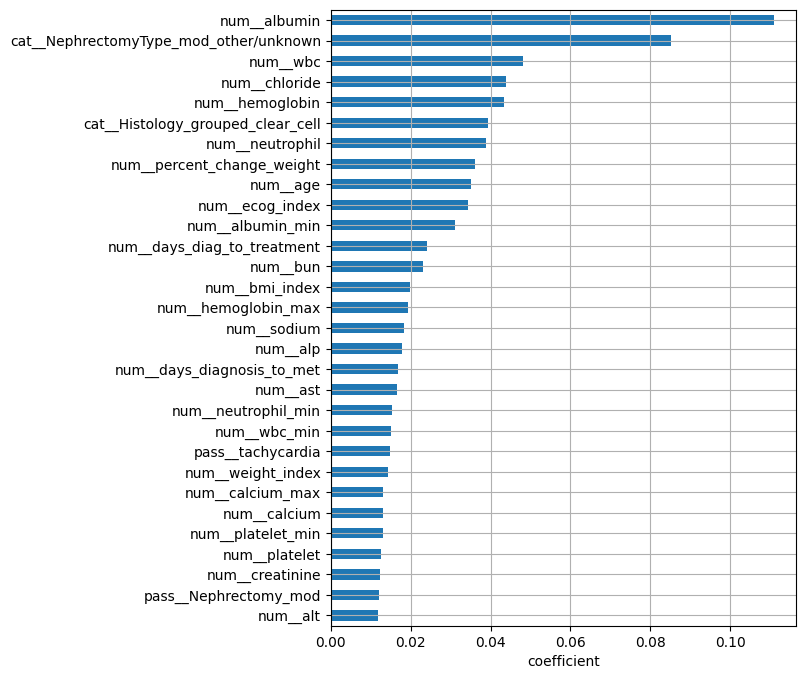

In [38]:
# Dataframe of coefficients for each variable 
gbm_feature_importance = pd.DataFrame(
    full_pipeline_final.named_steps['model'].feature_importances_,
    index = full_pipeline_final.named_steps['preprocessor'].get_feature_names_out(),
    columns = ['coefficient']
)

print('Total number of features: {}'.format(len(all_var)))

non_zero = np.sum(gbm_feature_importance.iloc[:, 0] != 0)
print('Number of non-zero features in final model: {}'.format(non_zero))

non_zero_coefs = gbm_feature_importance.query('coefficient != 0')
coef_order = non_zero_coefs.abs().sort_values('coefficient').tail(30).index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax = ax, legend = False)
ax.set_xlabel('coefficient')
ax.grid(True)

In [39]:
gbm_feature_importance = (
    gbm_feature_importance
    .reset_index()
    .rename(columns = {'index':'variable'})
)

In [40]:
gbm_feature_importance.to_csv('../outputs/gbm_feature_importance.csv', index = False, header = True)

## Calculating risk scores and probability survival
**Risk scores are calculated for each patient using 5-fold cross-validation. For each fold, a model is trained on 80% of the data, and risk scores are generated for patients in the held-out 20%. This approach ensures that each patient's risk score and probability survival is based on a model that does not include them in training, providing unbiased predictions.**

### Preprocessing

In [41]:
df = pd.concat([train_df, test_df])

In [42]:
df.shape

(8291, 197)

In [43]:
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [44]:
model_params = {
    'n_estimators': 700,
    'learning_rate': 0.05,
    'max_depth': 2,
    'subsample': 0.75,
    'max_features': 0.9,
    'verbose': 1,
    'random_state': 42
}

cv_scores_df = cross_validated_survival_predictions(
    df = df,                      
    y = y,                      
    all_var = all_var,                 
    preprocessor = preprocessor,            
    model_params = model_params,            
    survival_timepoints = (180, 365),     
    tau = 365,                     
    n_splits = 5,              
    random_state = 42,         
    verbose = True  
)

Processing fold 1/5
      Iter       Train Loss      OOB Improve   Remaining Time 
         1       23533.7715           4.8406            5.38m
         2       23345.6727        -146.5561            5.33m
         3       23411.5083          74.4103            5.28m
         4       23283.7195         -95.5686            5.26m
         5       23340.5859          67.2126            5.25m
         6       23494.2001         142.3982            5.24m
         7       23007.7034        -400.7496            5.23m
         8       23266.6307         231.4238            5.22m
         9       23472.5281         198.9609            5.21m
        10       23403.4996         -54.7780            5.20m
        20       23393.5413         229.1418            5.10m
        30       23223.7240          36.6510            5.02m
        40       23216.3286         191.3999            4.94m
        50       23126.3211          61.9070            4.86m
        60       22973.8788         -88.0433     

In [45]:
cv_scores_df.to_csv('../outputs/gb_survival_predictions.csv')